# AI Risk Manager — EDA
## Phase 3: Chargeback Evidence Responder

Explores `data/raw/chargebacks.csv` before model training.

Goals:
- Understand class balance (merchant wins vs losses)
- Find which evidence pieces matter most for winning
- Understand dispute reason patterns
- Identify features that separate wins from losses
- Check for missing values or data quality issues


---
## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('../data/raw/chargebacks.csv')
print(f'Shape  : {df.shape}')
print(f'Columns: {len(df.columns)}')
df.head(3)


Shape  : (8000, 34)
Columns: 34


,dispute_id,customer_id,merchant_id,order_value,product_category,payment_method,transaction_date,dispute_date,days_to_dispute,dispute_reason,...,is_late_dispute,is_high_value,is_first_order,is_new_account,is_serial_disputer,is_cod,evidence_score,dispute_difficulty,order_value_normalized,merchant_won
0,D_02216,C_10125,M_5067,7113.09,gift_cards,card,2025-12-10,2026-03-10,90,not_received,...,1,1,0,0,0,0,5,0.5,1.5819,1
1,D_02583,C_10519,M_5093,1967.47,luxury,upi,2026-03-06,2026-03-29,23,not_authorized,...,0,0,0,0,0,0,5,0.8,0.0656,1
2,D_01663,C_11512,M_5150,2827.31,luxury,card,2026-01-12,2026-03-17,64,not_received,...,1,0,0,0,0,0,5,0.5,0.2163,1


---
## 2. Basic Info

In [2]:
print('=== Data Types ===')
print(df.dtypes)
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'None')


=== Data Types ===
dispute_id                        str
customer_id                       str
merchant_id                       str
order_value                   float64
product_category                  str
payment_method                    str
transaction_date                  str
dispute_date                      str
days_to_dispute                 int64
dispute_reason                    str
delivery_confirmed              int64
delivery_days                   int64
customer_signed_delivery        int64
otp_used                        int64
ip_logs_available               int64
order_confirmation_sent         int64
refund_issued                   int64
customer_contacted_support      int64
customer_account_age_days       int64
customer_total_orders           int64
customer_past_disputes          int64
customer_avg_order_value      float64
merchant_chargeback_rate      float64
is_quick_dispute                int64
is_late_dispute                 int64
is_high_value                  

---
## 3. Class Balance

Expected: ~60% merchant wins, ~40% merchant losses.
Less imbalanced than Phase 1 and 2 — may not need class weights.


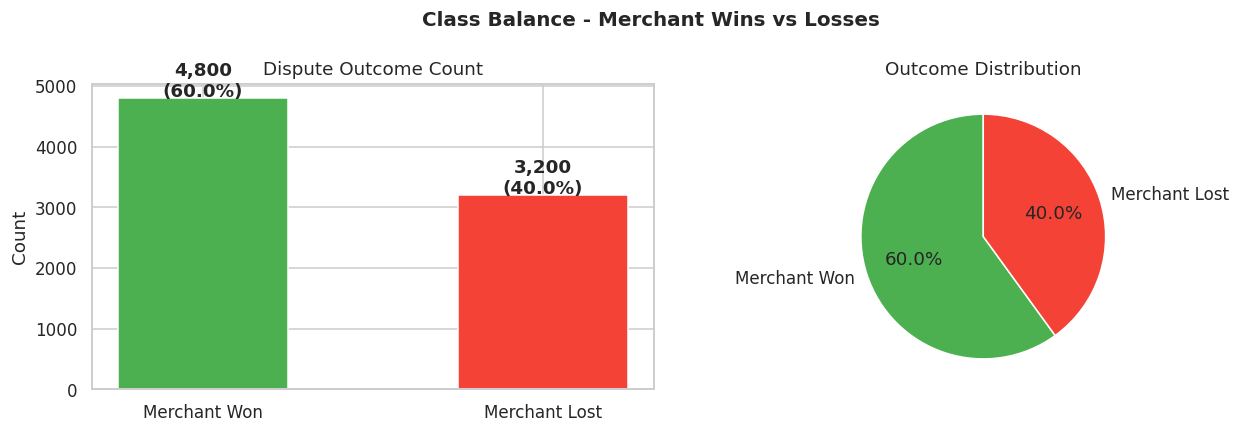

Merchant wins  : 4,800  (60.0%)
Merchant losses: 3,200  (40.0%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
n_wins   = df['merchant_won'].sum()
n_losses = len(df) - n_wins
labels   = ['Merchant Won', 'Merchant Lost']
colors   = ['#4CAF50', '#F44336']
vals     = [n_wins, n_losses]
axes[0].bar(labels, vals, color=colors, width=0.5)
axes[0].set_title('Dispute Outcome Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(vals):
    axes[0].text(i, v + 30, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].pie(vals, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Outcome Distribution')
plt.suptitle('Class Balance - Merchant Wins vs Losses', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Merchant wins  : {n_wins:,}  ({n_wins/len(df)*100:.1f}%)')
print(f'Merchant losses: {n_losses:,}  ({n_losses/len(df)*100:.1f}%)')


---
## 4. Dispute Reason Breakdown

Which dispute types are most common and which have the lowest win rate?


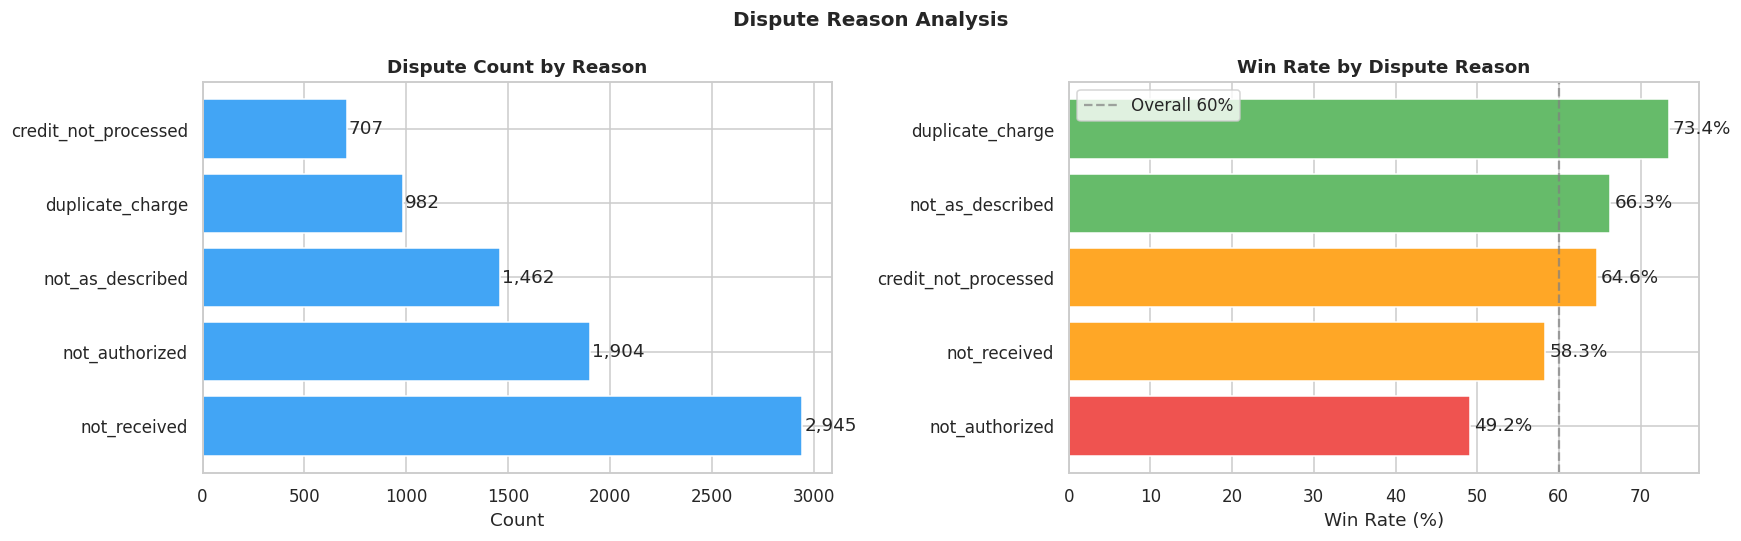

Win rate by dispute reason:
  duplicate_charge          73.4%
  not_as_described          66.3%
  credit_not_processed      64.6%
  not_received              58.3%
  not_authorized            49.2%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count by reason
reason_counts = df['dispute_reason'].value_counts()
axes[0].barh(reason_counts.index, reason_counts.values, color='#42A5F5')
axes[0].set_title('Dispute Count by Reason', fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(reason_counts.values):
    axes[0].text(v + 10, i, f'{v:,}', va='center')

# Win rate by reason
win_rates = df.groupby('dispute_reason')['merchant_won'].mean() * 100
win_rates = win_rates.sort_values()
colors_wr = ['#EF5350' if v < 55 else '#FFA726' if v < 65 else '#66BB6A'
             for v in win_rates.values]
axes[1].barh(win_rates.index, win_rates.values, color=colors_wr)
axes[1].set_title('Win Rate by Dispute Reason', fontweight='bold')
axes[1].set_xlabel('Win Rate (%)')
axes[1].axvline(x=60, color='gray', linestyle='--', alpha=0.7, label='Overall 60%')
axes[1].legend()
for i, v in enumerate(win_rates.values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center')
plt.suptitle('Dispute Reason Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Win rate by dispute reason:')
for reason, rate in win_rates.sort_values(ascending=False).items():
    print(f'  {reason:<25} {rate:.1f}%')


---
## 5. Evidence Score Distribution

Evidence score = sum of all evidence pieces available (0 to 5).
This is the single strongest predictor of winning a chargeback.


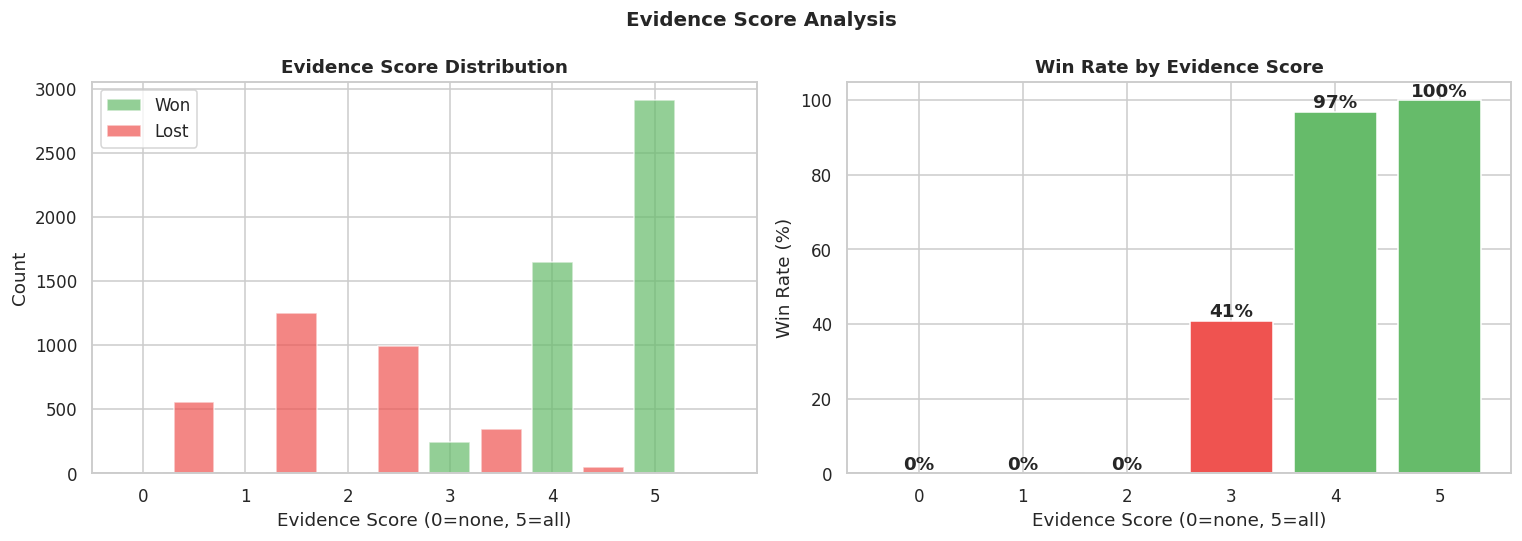

Avg evidence score - Wins  : 4.56 / 5
Avg evidence score - Losses: 1.40 / 5


In [5]:
wins   = df[df['merchant_won'] == True]
losses = df[df['merchant_won'] == False]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of evidence score
axes[0].hist(wins['evidence_score'], bins=range(0, 7), alpha=0.7,
             label='Won', color='#66BB6A', rwidth=0.4,
             align='left')
axes[0].hist(losses['evidence_score'], bins=range(0, 7), alpha=0.7,
             label='Lost', color='#EF5350', rwidth=0.4,
             align='mid')
axes[0].set_title('Evidence Score Distribution', fontweight='bold')
axes[0].set_xlabel('Evidence Score (0=none, 5=all)')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(0, 6))
axes[0].legend()

# Win rate by evidence score
win_by_evidence = df.groupby('evidence_score')['merchant_won'].mean() * 100
axes[1].bar(win_by_evidence.index, win_by_evidence.values,
            color=['#EF5350' if v < 50 else '#FFA726' if v < 75 else '#66BB6A'
                   for v in win_by_evidence.values])
axes[1].set_title('Win Rate by Evidence Score', fontweight='bold')
axes[1].set_xlabel('Evidence Score (0=none, 5=all)')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_xticks(range(0, 6))
for i, v in enumerate(win_by_evidence.values):
    axes[1].text(i, v + 1, f'{v:.0f}%', ha='center', fontweight='bold')
plt.suptitle('Evidence Score Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Avg evidence score - Wins  : {wins["evidence_score"].mean():.2f} / 5')
print(f'Avg evidence score - Losses: {losses["evidence_score"].mean():.2f} / 5')


---
## 6. Key Feature Comparison: Wins vs Losses


In [6]:
numeric_features = [
    'order_value', 'days_to_dispute', 'delivery_days',
    'evidence_score', 'customer_total_orders',
    'customer_account_age_days', 'customer_past_disputes',
    'order_value_normalized',
]

print(f"{'Feature':<35} {'Won Mean':<15} {'Lost Mean':<15} {'Diff %':<10}")
print('-' * 75)
for f in numeric_features:
    wm = wins[f].mean()
    lm = losses[f].mean()
    diff = ((wm - lm) / lm * 100) if lm != 0 else 0
    print(f'{f:<35} {wm:<15.2f} {lm:<15.2f} {diff:+.1f}%')


Feature                             Won Mean        Lost Mean       Diff %    
---------------------------------------------------------------------------
order_value                         4535.66         5922.86         -23.4%
days_to_dispute                     50.05           10.44           +379.6%
delivery_days                       4.50            9.90            -54.5%
evidence_score                      4.56            1.40            +224.3%
customer_total_orders               39.00           39.16           -0.4%
customer_account_age_days           876.11          883.97          -0.9%
customer_past_disputes              0.95            0.92            +3.1%
order_value_normalized              1.52            2.06            -26.0%


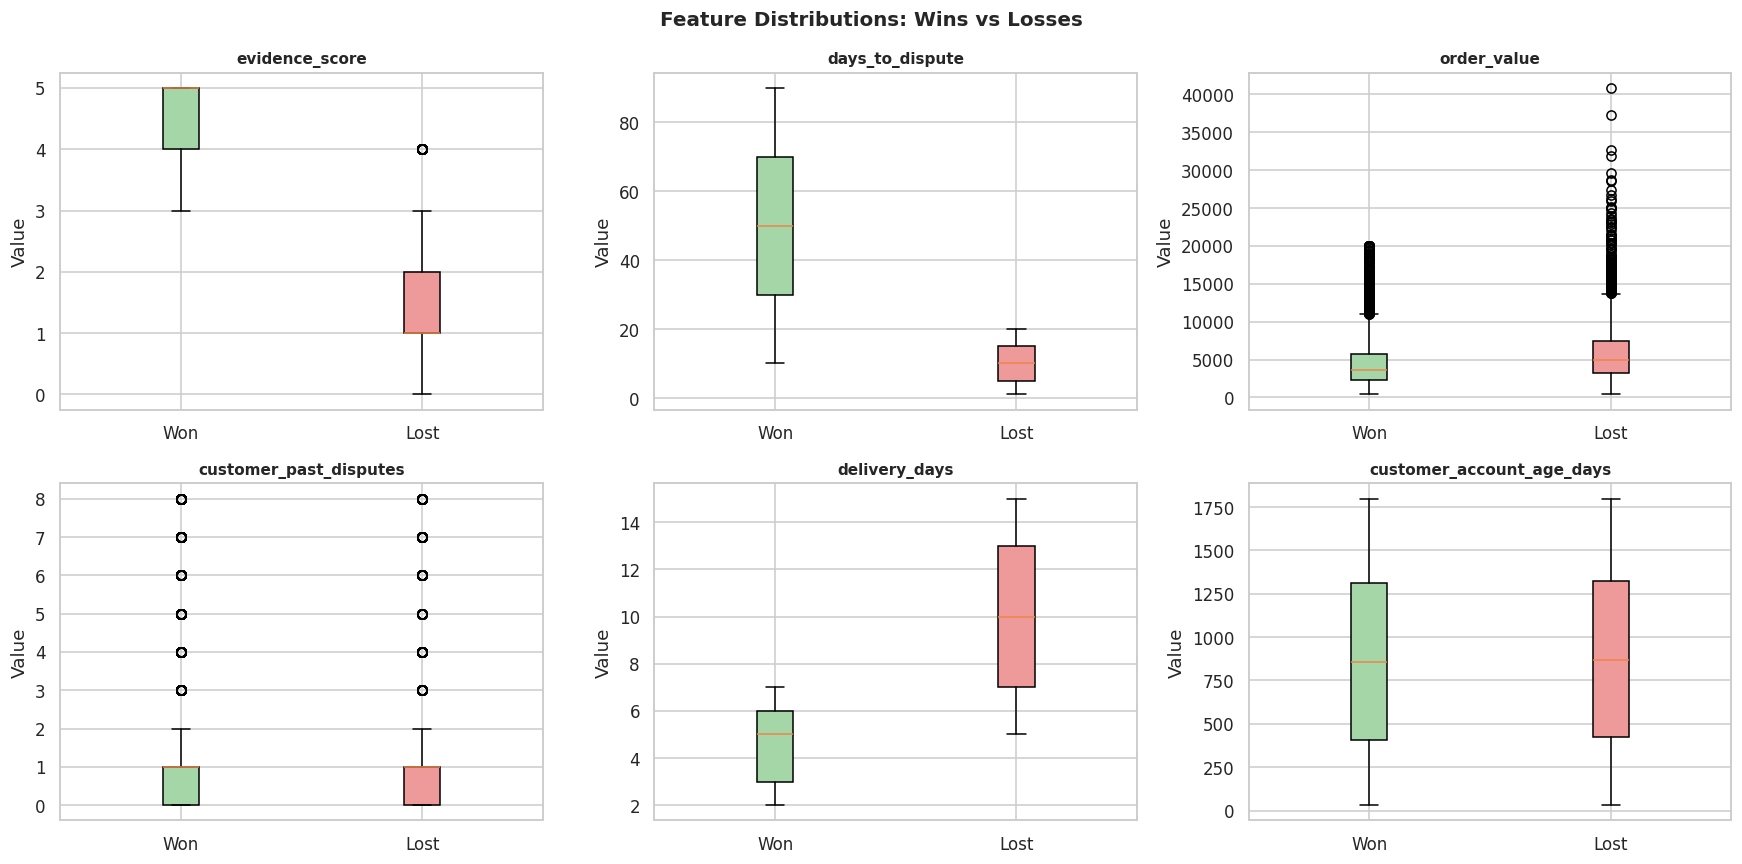

In [7]:
features_to_plot = [
    'evidence_score', 'days_to_dispute',
    'order_value', 'customer_past_disputes',
    'delivery_days', 'customer_account_age_days',
]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(features_to_plot):
    data = [wins[feat].values, losses[feat].values]
    bp = axes[i].boxplot(data, labels=['Won', 'Lost'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#A5D6A7')
    bp['boxes'][1].set_facecolor('#EF9A9A')
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Value')
plt.suptitle('Feature Distributions: Wins vs Losses', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 7. Binary Feature Rates

What % of wins vs losses has each boolean flag set?
Larger gap = stronger signal for the model.


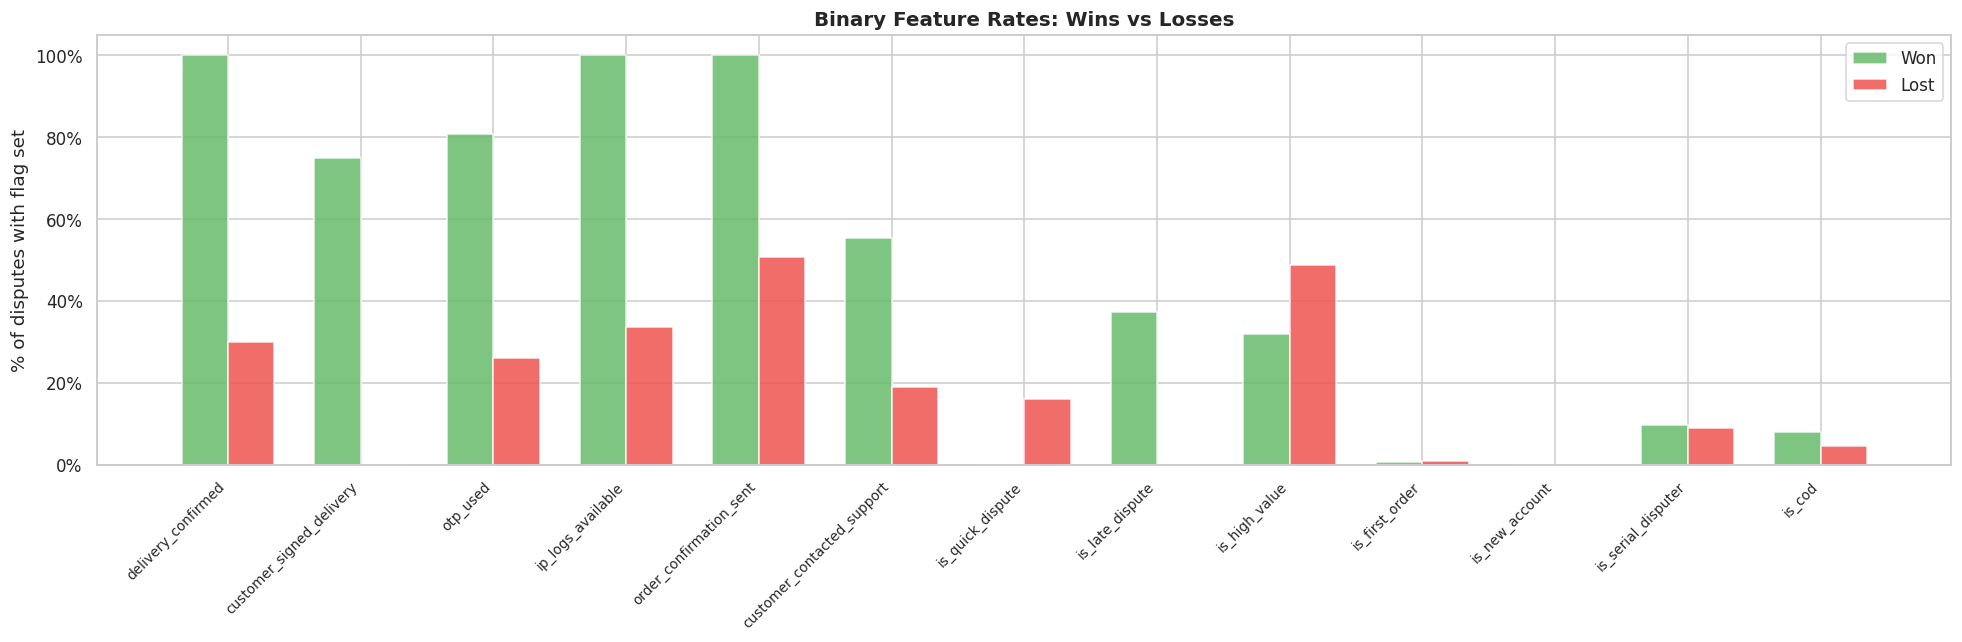

Feature                             Won %        Lost %       Gap       
----------------------------------------------------------------------
customer_signed_delivery            74.8         0.0          +74.8
delivery_confirmed                  100.0        29.9         +70.1
ip_logs_available                   100.0        33.8         +66.2
otp_used                            80.7         26.1         +54.6
order_confirmation_sent             100.0        50.7         +49.3
is_late_dispute                     37.3         0.0          +37.3
customer_contacted_support          55.5         18.9         +36.5
is_high_value                       31.9         48.8         -16.8
is_quick_dispute                    0.0          16.0         -16.0
is_cod                              8.0          4.7          +3.3
is_serial_disputer                  9.8          9.1          +0.7
is_first_order                      0.8          0.9          -0.1
is_new_account                      0.0    

In [8]:
binary_features = [
    'delivery_confirmed', 'customer_signed_delivery',
    'otp_used', 'ip_logs_available',
    'order_confirmation_sent', 'customer_contacted_support',
    'is_quick_dispute', 'is_late_dispute',
    'is_high_value', 'is_first_order',
    'is_new_account', 'is_serial_disputer', 'is_cod',
]
win_rates_bin  = [wins[f].mean() * 100 for f in binary_features]
loss_rates_bin = [losses[f].mean() * 100 for f in binary_features]

x = np.arange(len(binary_features))
width = 0.35
fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(x - width/2, win_rates_bin,  width, label='Won',  color='#66BB6A', alpha=0.85)
ax.bar(x + width/2, loss_rates_bin, width, label='Lost', color='#EF5350', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(binary_features, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('% of disputes with flag set')
ax.set_title('Binary Feature Rates: Wins vs Losses', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.show()

print(f"{'Feature':<35} {'Won %':<12} {'Lost %':<12} {'Gap':<10}")
print('-' * 70)
for f, wr, lr in sorted(zip(binary_features, win_rates_bin, loss_rates_bin),
                         key=lambda x: abs(x[1]-x[2]), reverse=True):
    print(f'{f:<35} {wr:<12.1f} {lr:<12.1f} {wr-lr:+.1f}')


---
## 8. Days to Dispute Analysis

Quick disputes (within 3 days) vs late disputes (after 60 days).
Pattern: Losses tend to be disputed much faster.


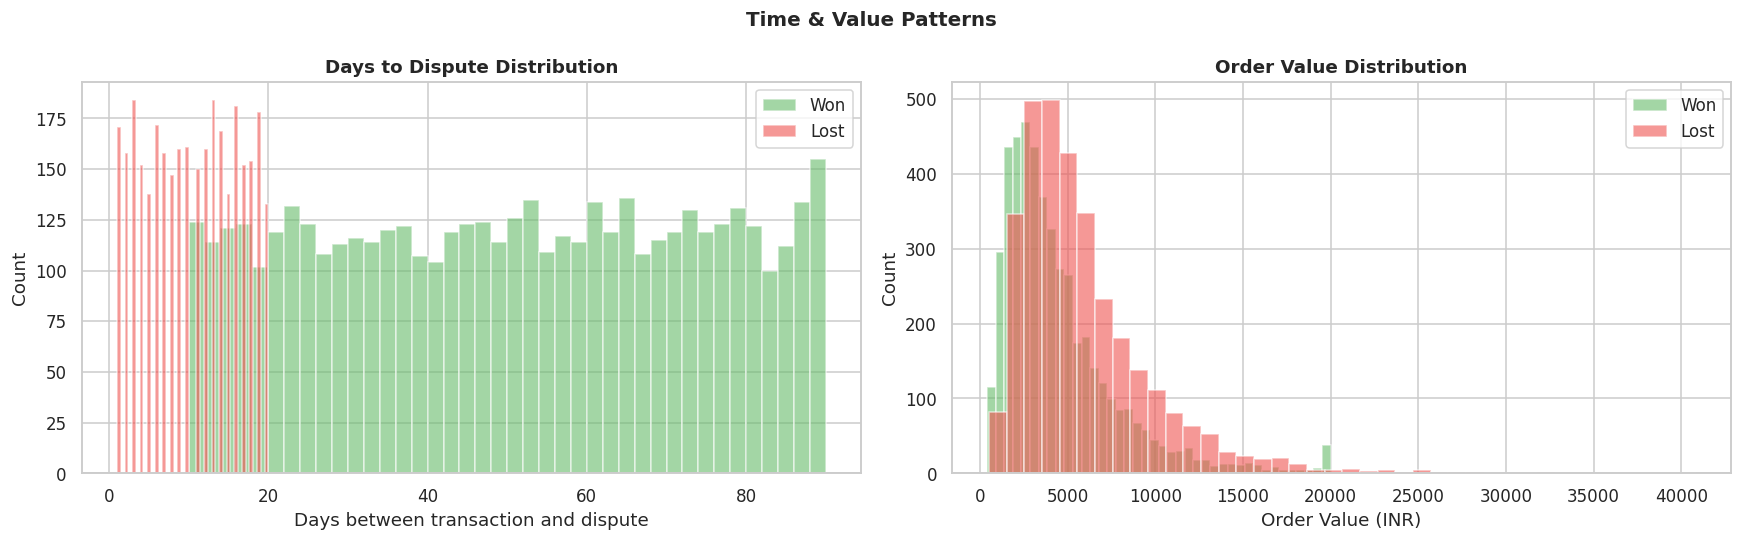

Avg days to dispute - Wins  : 50.1 days
Avg days to dispute - Losses: 10.4 days


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution
axes[0].hist(wins['days_to_dispute'], bins=40, alpha=0.6,
             label='Won', color='#66BB6A')
axes[0].hist(losses['days_to_dispute'], bins=40, alpha=0.6,
             label='Lost', color='#EF5350')
axes[0].set_title('Days to Dispute Distribution', fontweight='bold')
axes[0].set_xlabel('Days between transaction and dispute')
axes[0].set_ylabel('Count')
axes[0].legend()

# Order value distribution
axes[1].hist(wins['order_value'], bins=40, alpha=0.6,
             label='Won', color='#66BB6A')
axes[1].hist(losses['order_value'], bins=40, alpha=0.6,
             label='Lost', color='#EF5350')
axes[1].set_title('Order Value Distribution', fontweight='bold')
axes[1].set_xlabel('Order Value (INR)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Time & Value Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Avg days to dispute - Wins  : {wins["days_to_dispute"].mean():.1f} days')
print(f'Avg days to dispute - Losses: {losses["days_to_dispute"].mean():.1f} days')


---
## 9. Correlation Heatmap

Which features are most correlated with `merchant_won`?


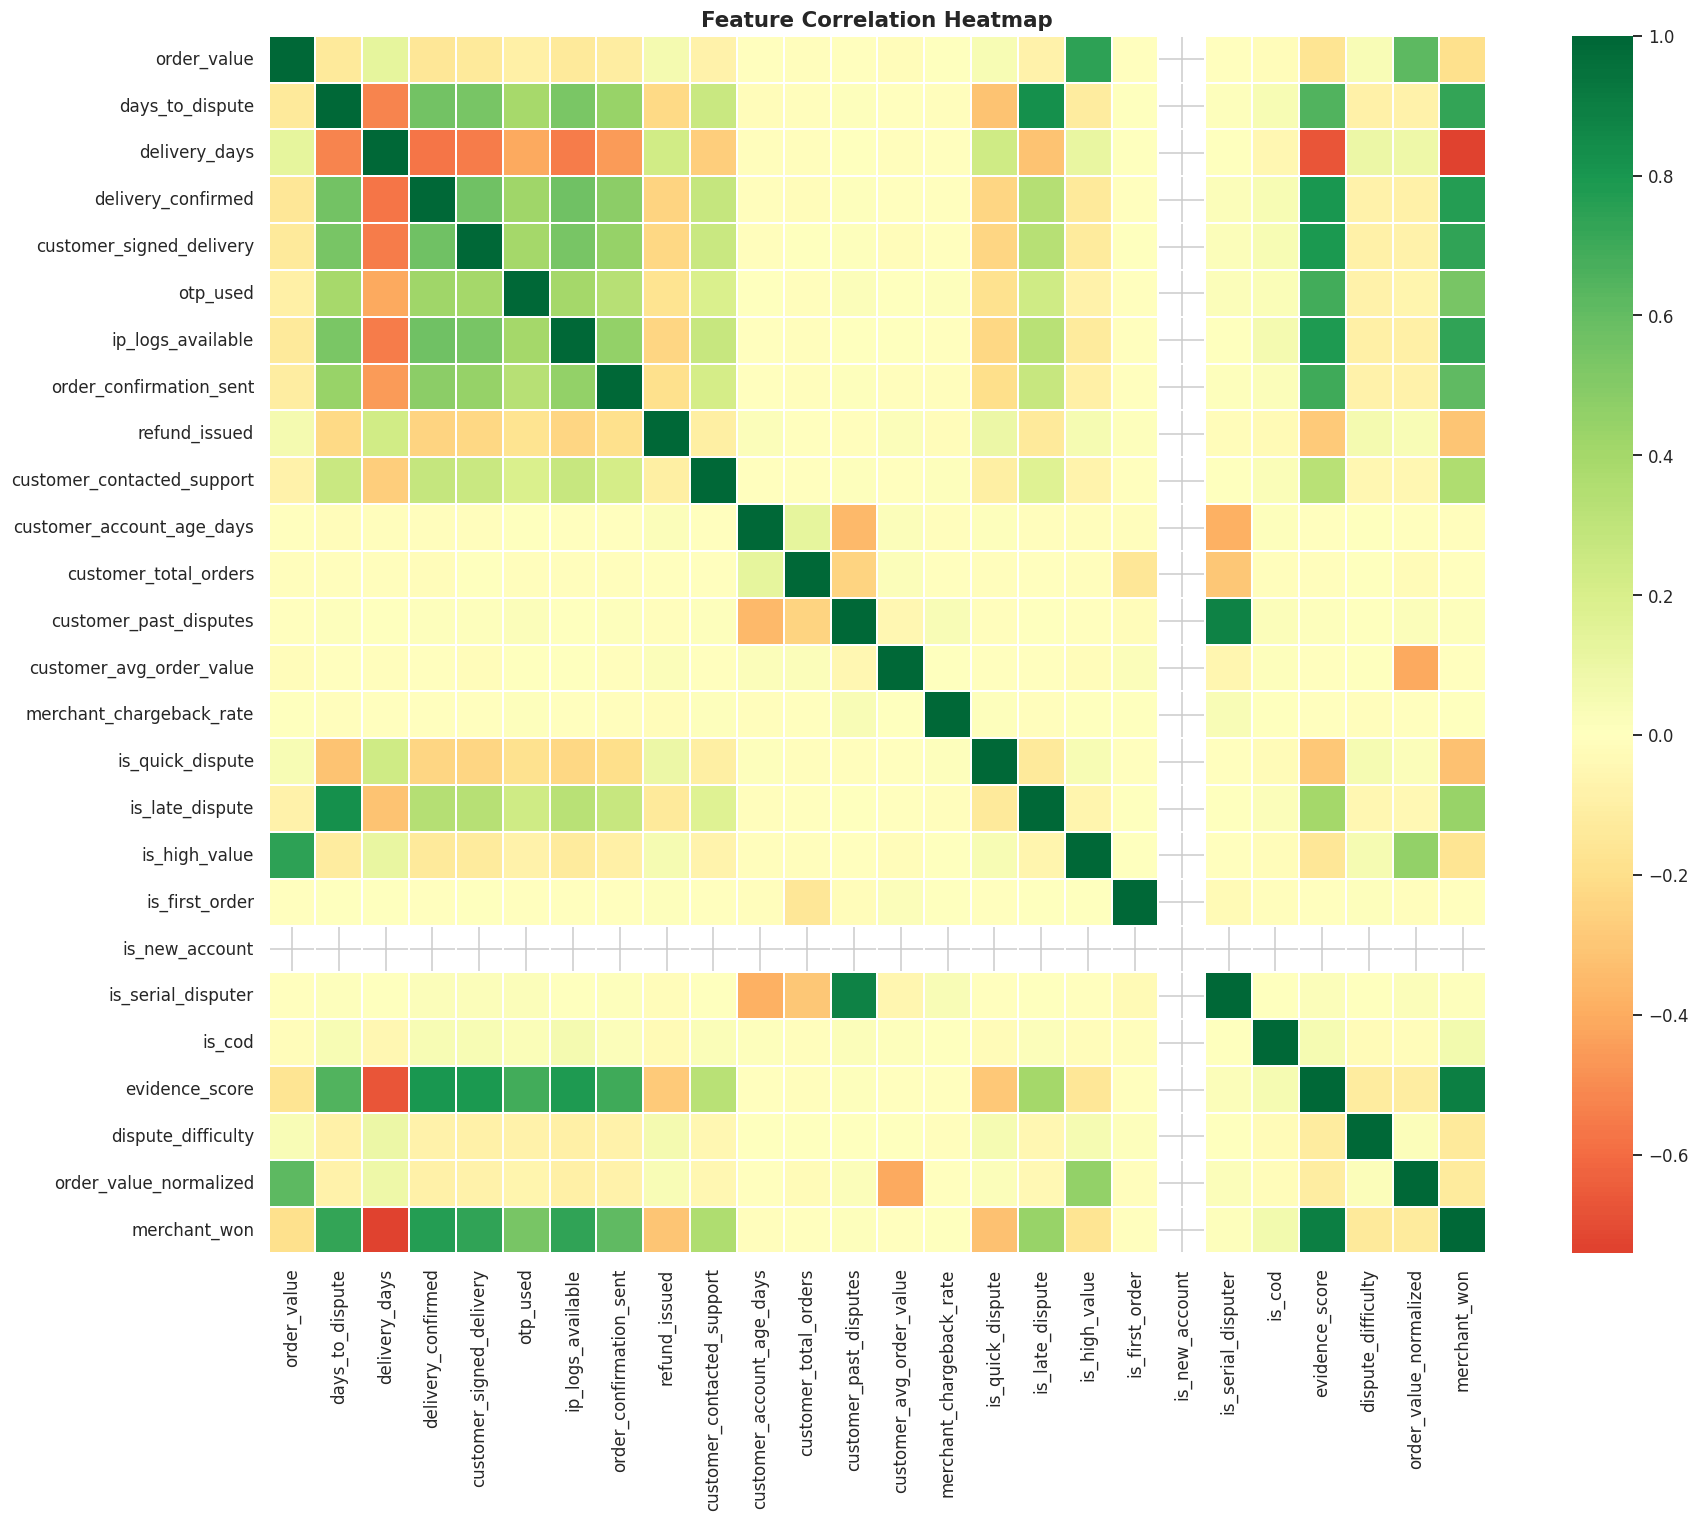

Top correlations with merchant_won:
  evidence_score                      +0.8984
  delivery_confirmed                  +0.7642
  delivery_days                       -0.7415
  customer_signed_delivery            +0.7371
  ip_logs_available                   +0.7352
  days_to_dispute                     +0.7258
  order_confirmation_sent             +0.6073
  otp_used                            +0.5440
  is_late_dispute                     +0.4385
  customer_contacted_support          +0.3640
  is_quick_dispute                    -0.3206
  refund_issued                       -0.3081
  order_value                         -0.1847
  is_high_value                       -0.1694
  dispute_difficulty                  -0.1337


In [10]:
model_features = [
    'order_value', 'days_to_dispute', 'delivery_days',
    'delivery_confirmed', 'customer_signed_delivery',
    'otp_used', 'ip_logs_available', 'order_confirmation_sent',
    'refund_issued', 'customer_contacted_support',
    'customer_account_age_days', 'customer_total_orders',
    'customer_past_disputes', 'customer_avg_order_value',
    'merchant_chargeback_rate',
    'is_quick_dispute', 'is_late_dispute', 'is_high_value',
    'is_first_order', 'is_new_account', 'is_serial_disputer',
    'is_cod', 'evidence_score', 'dispute_difficulty',
    'order_value_normalized', 'merchant_won',
]
corr = df[model_features].corr()
fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr, annot=False, cmap='RdYlGn', center=0,
            linewidths=0.3, ax=ax, square=True)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top correlations with merchant_won:')
won_corr = corr['merchant_won'].drop('merchant_won').abs().sort_values(ascending=False)
for feat, val in won_corr.head(15).items():
    direction = '+' if corr['merchant_won'][feat] > 0 else '-'
    print(f'  {feat:<35} {direction}{val:.4f}')


---
## 10. Win Rate by Dispute Reason x Evidence Score

How does evidence score affect win rate for each dispute type?


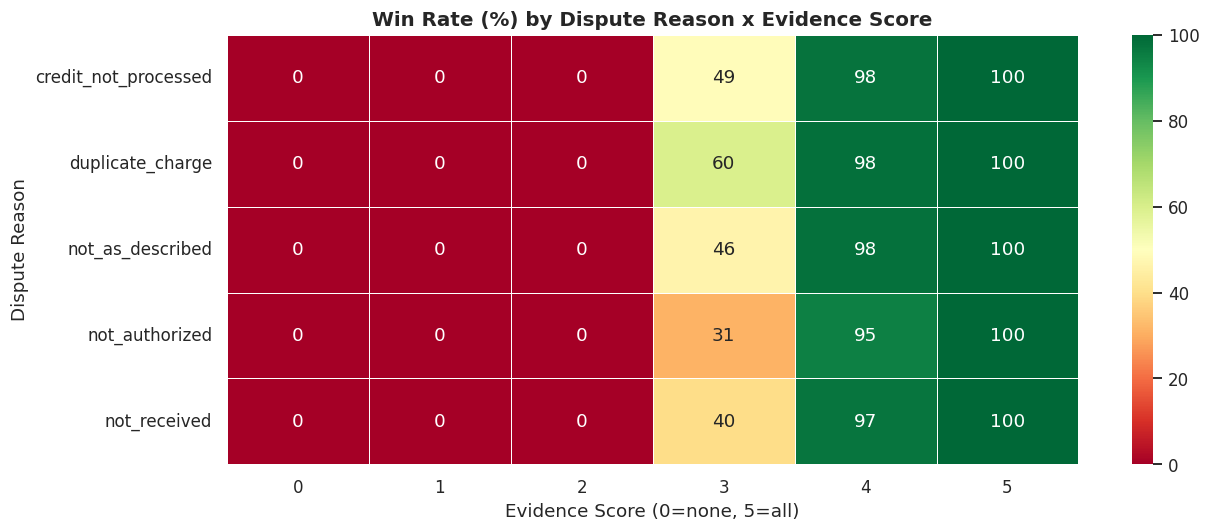

In [11]:
pivot = df.groupby(['dispute_reason', 'evidence_score'])['merchant_won'].mean() * 100
pivot = pivot.unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=0, vmax=100, ax=ax, linewidths=0.5)
ax.set_title('Win Rate (%) by Dispute Reason x Evidence Score',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Evidence Score (0=none, 5=all)')
ax.set_ylabel('Dispute Reason')
plt.tight_layout()
plt.show()


---
## 11. EDA Summary


In [12]:
print('=' * 60)
print('  EDA SUMMARY - Phase 3: Chargeback Evidence Responder')
print('=' * 60)
win_pct = df['merchant_won'].mean() * 100
print(f'  Class balance    : {win_pct:.1f}% wins / {100-win_pct:.1f}% losses')
print(f'  Missing values   : {df.isnull().sum().sum()}')
print()
print('  Most important features for winning:')
top_signals = [
    ('evidence_score',          'Evidence score (0-5)',             True),
    ('delivery_confirmed',      'Delivery confirmed',               True),
    ('ip_logs_available',       'IP logs available',                True),
    ('customer_signed_delivery','Customer signed for delivery',     True),
    ('otp_used',                'OTP used during purchase',         True),
    ('is_quick_dispute',        'Dispute filed within 3 days',      False),
    ('dispute_difficulty',      'Dispute type difficulty',          False),
]
for col, label, positive in top_signals:
    wv = wins[col].mean()
    lv = losses[col].mean()
    arrow = 'HELPS win' if positive else 'HURTS chances'
    print(f'    {label:<35} won: {wv:.2f}  lost: {lv:.2f}  ({arrow})')
print()
print('  Win rate by dispute reason:')
for reason, rate in df.groupby('dispute_reason')['merchant_won'].mean().sort_values(ascending=False).items():
    print(f'    {reason:<25} {rate*100:.1f}%')
print()
print(f'  Total features available: {len(model_features)-1}')
print('  Key recommendation: evidence_score is the strongest predictor.')
print('  Models with evidence_score >= 4 win ~95% of disputes.')
print('=' * 60)


  EDA SUMMARY - Phase 3: Chargeback Evidence Responder
  Class balance    : 60.0% wins / 40.0% losses
  Missing values   : 0

  Most important features for winning:
    Evidence score (0-5)                won: 4.56  lost: 1.40  (HELPS win)
    Delivery confirmed                  won: 1.00  lost: 0.30  (HELPS win)
    IP logs available                   won: 1.00  lost: 0.34  (HELPS win)
    Customer signed for delivery        won: 0.75  lost: 0.00  (HELPS win)
    OTP used during purchase            won: 0.81  lost: 0.26  (HELPS win)
    Dispute filed within 3 days         won: 0.00  lost: 0.16  (HURTS chances)
    Dispute type difficulty             won: 0.52  lost: 0.57  (HURTS chances)

  Win rate by dispute reason:
    duplicate_charge          73.4%
    not_as_described          66.3%
    credit_not_processed      64.6%
    not_received              58.3%
    not_authorized            49.2%

  Total features available: 25
  Key recommendation: evidence_score is the strongest predi